# Data

#data from "https://www.kaggle.com/datasets/chitwanmanchanda/fraudulent-transactions-data?resource=download"

## API Data

Api token Kaggle = 'KGAT_f7b8f57226c62a0408c3b26e8c3873f1'

In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od

dataset_url = "https://www.kaggle.com/datasets/chitwanmanchanda/fraudulent-transactions-data?resource=download"
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: akialgrowto
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/chitwanmanchanda/fraudulent-transactions-data


100%|██████████| 178M/178M [00:06<00:00, 28.1MB/s]


## Data Fraud

Data untuk kasus ini tersedia dalam format CSV dengan 6362620 baris dan 10 kolom.

Kamus Data:

Langkah - memetakan satuan waktu di dunia nyata. Dalam hal ini, 1 langkah sama dengan 1 jam waktu. Total langkah 744 (simulasi 30 hari).

Jenis - SETORAN TUNAI, PENGELUARAN TUNAI, DEBIT, PEMBAYARAN, dan TRANSFER.

jumlah - jumlah transaksi dalam mata uang lokal.

nameOrig - pelanggan yang memulai transaksi

oldbalanceOrg - saldo awal sebelum transaksi

newbalanceOrig - saldo baru setelah transaksi

nameDest - pelanggan yang merupakan penerima transaksi

oldbalanceDest - penerima saldo awal sebelum transaksi. Perhatikan bahwa tidak ada informasi untuk pelanggan yang diawali dengan huruf M (Merchant).

newbalanceDest - penerima saldo baru setelah transaksi. Perhatikan bahwa tidak ada informasi untuk pelanggan yang diawali dengan huruf M (Merchant).

isFraud - Ini adalah transaksi yang dilakukan oleh agen penipu di dalam simulasi. Dalam dataset khusus ini, perilaku curang para agen bertujuan untuk mendapatkan keuntungan dengan mengambil alih akun pelanggan dan mencoba menguras dana dengan mentransfernya ke akun lain lalu menarik uang dari sistem.

isFlaggedFraud - Model bisnis ini bertujuan untuk mengontrol transfer besar-besaran dari satu akun ke akun lain dan menandai upaya ilegal. Upaya ilegal dalam dataset ini adalah upaya untuk mentransfer lebih dari 200.000 dalam satu transaksi.

In [3]:
!pip install inflection
!pip install boruta
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.4 MB/s eta 0:00:00


In [4]:
import joblib
import warnings
import inflection

import numpy             as np
import pandas            as pd
import seaborn           as sns

import matplotlib.pyplot as plt

from scipy   import stats
from boruta  import BorutaPy
from category_encoders import OneHotEncoder

from IPython.display      import Image
from IPython.core.display import HTML

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.svm          import SVC
from sklearn.dummy        import DummyClassifier
from sklearn.ensemble     import RandomForestClassifier
from sklearn.neighbors    import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics         import balanced_accuracy_score, precision_score, classification_report
from sklearn.metrics         import recall_score, f1_score, make_scorer, cohen_kappa_score
from sklearn.preprocessing   import MinMaxScaler
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold, cross_val_score

In [5]:
import pandas as pd

# Ganti 'nama_file.csv' dengan nama file yang baru saja kamu upload
df = pd.read_csv('/content/fraudulent-transactions-data/Fraud.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [7]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [8]:
print('Number of Rows: {}'.format(df.shape[0]))
print('Number of Cols: {}'.format(df.shape[1]))

Number of Rows: 6362620
Number of Cols: 11


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


# Data Preprocessing

In [10]:
df1 = df.copy()

In [11]:
cols_old = df1.columns.tolist()

snakecase = lambda x: inflection.underscore(x)
cols_new = list(map(snakecase, cols_old))

df1.columns = cols_new

In [12]:
df1.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
6362615,False
6362616,False
6362617,False
6362618,False


In [ ]:
df1.isnull().sum()

,0
step,0
type,0
amount,0
name_orig,0
oldbalance_org,0
newbalance_orig,0
name_dest,0
oldbalance_dest,0
newbalance_dest,0
is_fraud,0


Merubah tipe data agar lebih mudah dipahami saat visualisasi

In [13]:
df1['is_fraud'] = df1['is_fraud'].map({1: 'yes', 0: 'no'})
df1['is_flagged_fraud'] = df1['is_flagged_fraud'].map({1: 'yes', 0: 'no'})

# Explanatory Data Analysis

In [14]:
num_attributes = df1.select_dtypes(exclude='object')
cat_attributes = df1.select_dtypes(include='object')

In [ ]:
describe = num_attributes.describe().T

describe['range'] = (num_attributes.max() - num_attributes.min()).tolist()
describe['variation coefficient'] = (num_attributes.std() / num_attributes.mean()).tolist()
describe['skew'] = num_attributes.skew().tolist()
describe['kurtosis'] = num_attributes.kurtosis().tolist()

describe

,count,mean,std,min,25%,50%,75%,max,range,variation coefficient,skew,kurtosis
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02,7.420000e+02,0.584772,0.375177,0.329071
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07,9.244552e+07,3.357344,30.993949,1797.956705
oldbalance_org,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07,5.958504e+07,3.463606,5.249136,32.964879
newbalance_orig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07,4.958504e+07,3.419485,5.176884,32.066985
oldbalance_dest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08,3.560159e+08,3.088194,19.921758,948.674125
newbalance_dest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08,3.561793e+08,2.999298,19.352302,862.156508


In [ ]:
cat_attributes.describe()

,type,name_orig,name_dest,is_fraud,is_flagged_fraud
count,6362620,6362620,6362620,6362620,6362620
unique,5,6353307,2722362,2,2
top,CASH_OUT,C1530544995,C1286084959,no,no
freq,2237500,3,113,6354407,6362604


In [20]:
df2 = df1.copy()

In [21]:
# melihat pola apakah akhir pekan atau hari tertentu
df2['step_days'] = df2['step'].apply(lambda i: i/24)
df2['step_weeks'] = df2['step'].apply(lambda i: i/(24*7))

# difference between initial balance before the transaction and new balance after the transaction
df2['diff_new_old_balance'] = df2['newbalance_orig'] - df2['oldbalance_org']

# difference between initial balance recipient before the transaction and new balance recipient after the transaction.
df2['diff_new_old_destiny'] = df2['newbalance_dest'] - df2['oldbalance_dest']

# name orig and name dest
df2['name_orig'] = df2['name_orig'].apply(lambda i: i[0])
df2['name_dest'] = df2['name_dest'].apply(lambda i: i[0])

In [22]:
print("\nDistribusi Kelas (Fraud vs Legitimate):")
fraud_counts = df2['is_fraud'].value_counts()
print(fraud_counts)

# dalam persen
print("\nPersentase Distribusi:")
print(df2['is_fraud'].value_counts(normalize=True) * 100)


Distribusi Kelas (Fraud vs Legitimate):
is_fraud
no     6354407
yes       8213
Name: count, dtype: int64

Persentase Distribusi:
is_fraud
no     99.870918
yes     0.129082
Name: proportion, dtype: float64


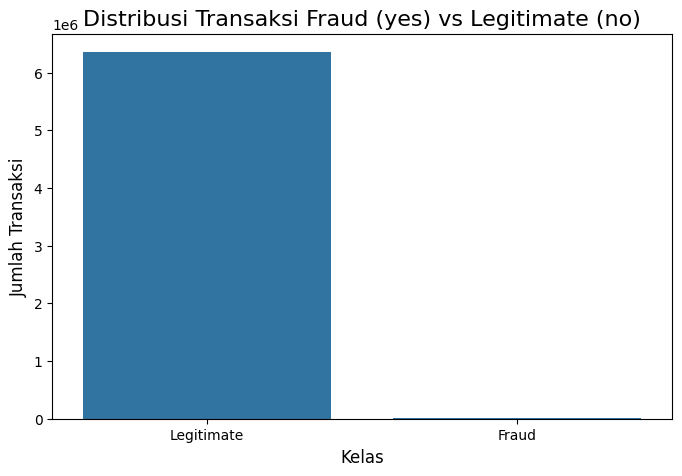

In [ ]:
# Visualisasi distribusi kelas
plt.figure(figsize=(8, 5))
sns.countplot(x='is_fraud', data=df1, color = 'yellow')
plt.title('Distribusi Transaksi Fraud (yes) vs Legitimate (no)', fontsize=16)
plt.xlabel('Kelas', fontsize=12)
plt.ylabel('Jumlah Transaksi', fontsize=12)
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.show()

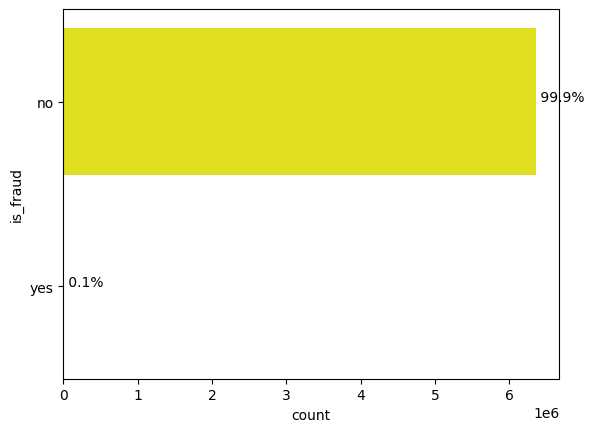

In [ ]:
ax = sns.countplot(y='is_fraud', data=df1, color="yellow");

total = df1['is_fraud'].size
for p in ax.patches:
        percentage = ' {:.1f}%'.format(100 * p.get_width()/total)
        x = p.get_x() + p.get_width() + 0.02
        y = p.get_y() + p.get_height()/2
        ax.annotate(percentage, (x, y))

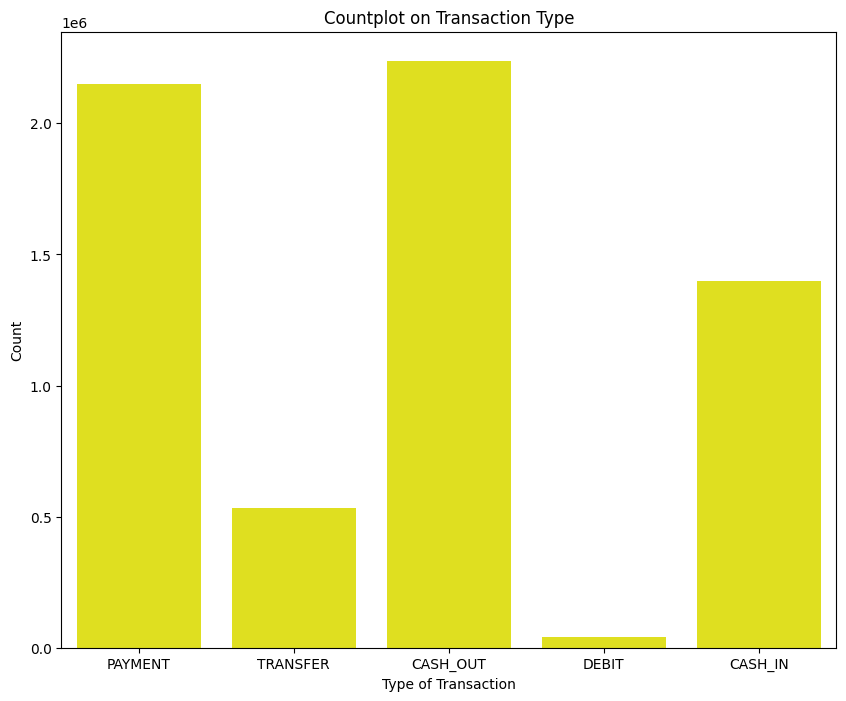

In [ ]:
plt.figure(figsize=(10,8))

sns.countplot(x='type', data=df1, color='yellow')

plt.title('Countplot on Transaction Type')
plt.xlabel('Type of Transaction')
plt.ylabel('Count')
plt.show()

## Analisis Bivariat

Analisis Bivariat
Melihat transaksi fraud dari C/M ke C/M

Dapat dilihat transaksi Fraud itu merupakan transaksi dari C ke C atau Kostumer ke Kostomer

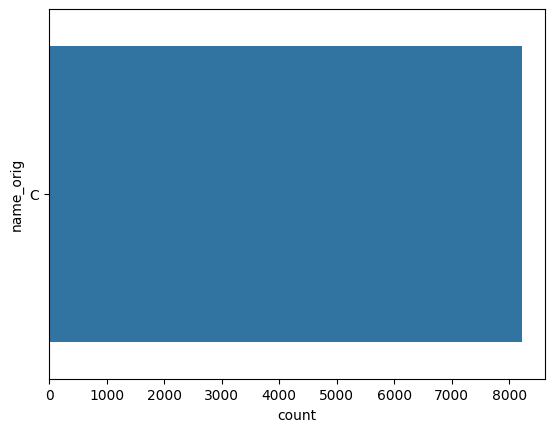

In [23]:
data_fraud = df2[df2['is_fraud'] == 'yes']
sns.countplot(y='name_orig', data=data_fraud);

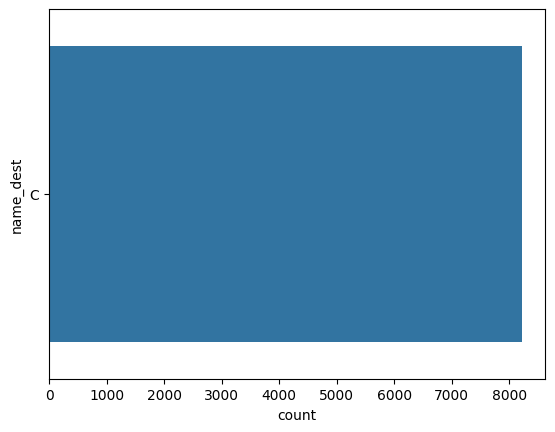

In [25]:
sns.countplot(y='name_dest', data=data_fraud);

Dalam Distribusi, amount atau nilai terkecil dalam transaksi yaitu 13389.57. Ini berarti transaksi fraud berada di lebih dari 10000

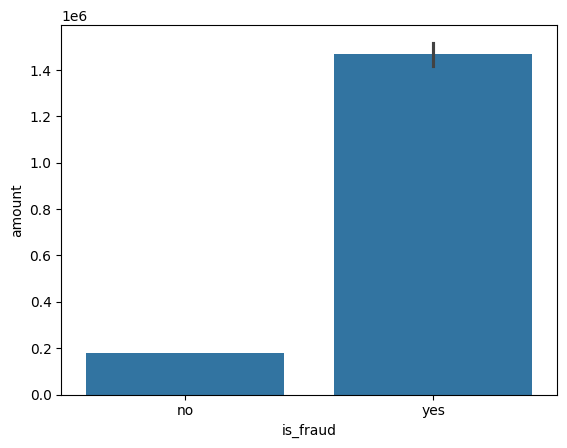

In [26]:
sns.barplot(y='amount', x='is_fraud', data=df2);

Transaksi fraud kebanyakan menggunakan tipe cash out dan transfer

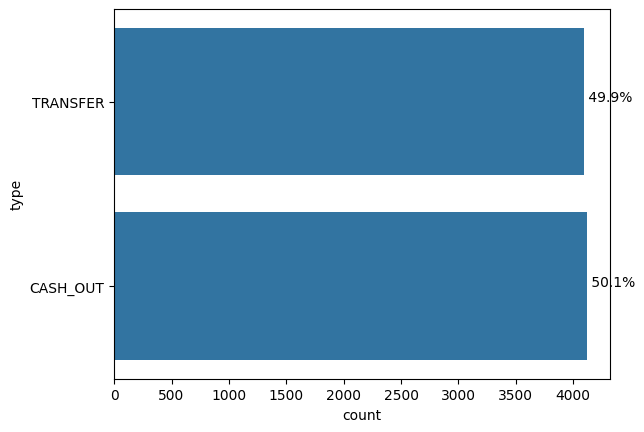

In [27]:
aux1 = df2[df2['is_fraud'] == 'yes']
ax = sns.countplot(y='type', data=aux1)

total = aux1['type'].size
for p in ax.patches:
        percentage = ' {:.1f}%'.format(100 * p.get_width()/total)
        x = p.get_x() + p.get_width() + 0.02
        y = p.get_y() + p.get_height()/2
        ax.annotate(percentage, (x, y))

Transaksi bukan fraud tipenya menyeluruh dan paling banyak tipe cash out

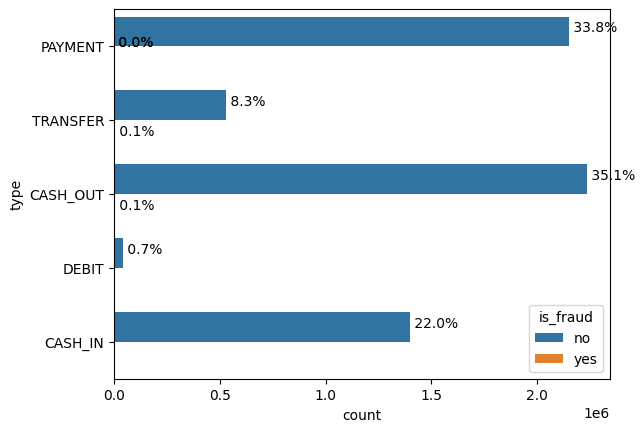

In [28]:
ax = sns.countplot(y='type', hue='is_fraud', data=df2)

total = df2['type'].size
for p in ax.patches:
        percentage = ' {:.1f}%'.format(100 * p.get_width()/total)
        x = p.get_x() + p.get_width() + 0.02
        y = p.get_y() + p.get_height()/2
        ax.annotate(percentage, (x, y))

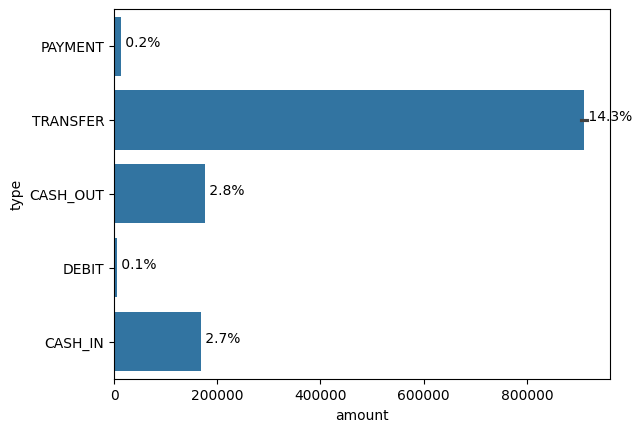

In [29]:
ax = sns.barplot(y='type', x='amount', data=df2);

total = df2['type'].size
for p in ax.patches:
        percentage = ' {:.1f}%'.format(100 * p.get_width()/total)
        x = p.get_x() + p.get_width() + 0.02
        y = p.get_y() + p.get_height()/2
        ax.annotate(percentage, (x, y))

Melihat transaksi fraud perhari dan valuenya

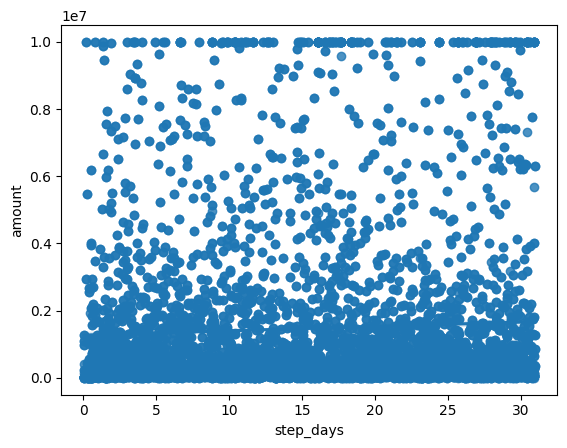

In [30]:
aux1 = df2[df2['is_fraud'] == 'yes']
sns.regplot(x='step_days', y='amount', data=aux1);

## Analisis Multivariat

Variabel Numerik (korelasi)

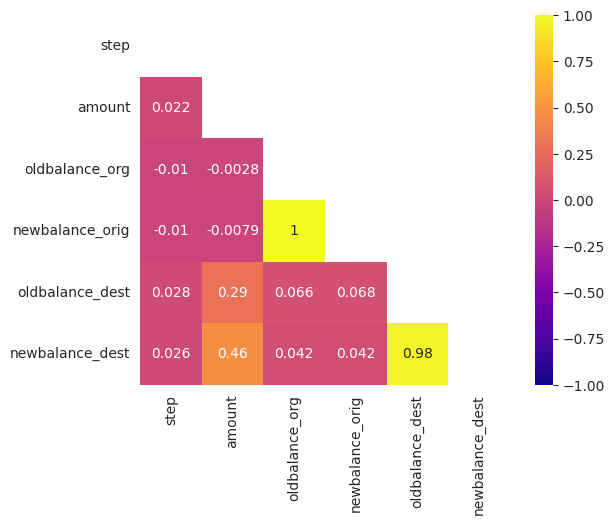

In [31]:
corr = num_attributes.corr()

mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

with sns.axes_style("white"):
    ax = sns.heatmap(corr, annot=True, mask=mask, cmap='plasma', vmin=-1, center=0, vmax=1, square=True)

# Data Preparation

In [32]:
df3 = df2.copy()

Split data ke Train dan Test

In [33]:
X = df3.drop(columns=['is_fraud', 'is_flagged_fraud', 'name_orig', 'name_dest',
                      'step_weeks', 'step_days'], axis=1)
y = df3['is_fraud'].map({'yes': 1, 'no': 0})

In [34]:
# spliting into temp and test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=.2, stratify=y)

In [35]:
# spliting into train and valid
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=.2, stratify=y_temp)

One Hot Encoder (mengubah kategorik menjadi numerik)

In [36]:
ohe = OneHotEncoder(cols=['type'], use_cat_names=True)

X_train = ohe.fit_transform(X_train)
X_valid = ohe.transform(X_valid)

X_temp = ohe.fit_transform(X_temp)
X_test = ohe.transform(X_test)

Rescalling agar skala angka denga data tipe kategorik sama

In [37]:
num_columns = ['amount', 'oldbalance_org', 'newbalance_orig', 'oldbalance_dest', 'newbalance_dest',
               'diff_new_old_balance', 'diff_new_old_destiny']
mm = MinMaxScaler()
X_params = X_temp.copy()

X_train[num_columns] = mm.fit_transform(X_train[num_columns])
X_valid[num_columns] = mm.transform(X_valid[num_columns])

X_params[num_columns] = mm.fit_transform(X_temp[num_columns])
X_test[num_columns] = mm.transform(X_test[num_columns])

 memilih colom yang berpengaruh

In [38]:
final_columns_selected = ['step', 'oldbalance_org',
                          'newbalance_orig', 'newbalance_dest',
                          'diff_new_old_balance', 'diff_new_old_destiny',
                          'type_TRANSFER']

# Machine Learning Modelling

In [39]:
X_train_cs = X_train[final_columns_selected]
X_valid_cs = X_valid[final_columns_selected]

X_temp_cs = X_temp[final_columns_selected]
X_test_cs = X_test[final_columns_selected]

X_params_cs = X_params[final_columns_selected]

## Dummy Clasiffier

Model dummy sebagai pembanding model kita

In [40]:
dummy = DummyClassifier()
dummy.fit(X_train_cs, y_train)

y_pred = dummy.predict(X_valid_cs)

In [41]:
def ml_scores(model_name, y_true, y_pred):
    scores = {
        'model': model_name,
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred)
    }
    return pd.DataFrame(scores, index=[0])

dummy_results = ml_scores('dummy', y_valid, y_pred)
dummy_results

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,model,balanced_accuracy,precision,recall,f1_score,cohen_kappa
0,dummy,0.5,0.0,0.0,0.0,0.0


Classification report

In [42]:
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1016706
           1       0.00      0.00      0.00      1314

    accuracy                           1.00   1018020
   macro avg       0.50      0.50      0.50   1018020
weighted avg       1.00      1.00      1.00   1018020



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Logistic Regression

In [43]:
lg = LogisticRegression()
lg.fit(X_train_cs, y_train)

y_pred = lg.predict(X_valid_cs)

In [44]:
lg_results = ml_scores('Logistic Regression', y_valid, y_pred)
lg_results

,model,balanced_accuracy,precision,recall,f1_score,cohen_kappa
0,Logistic Regression,0.508371,1.0,0.016743,0.032934,0.032893


Classification report

In [45]:
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1016706
           1       1.00      0.02      0.03      1314

    accuracy                           1.00   1018020
   macro avg       1.00      0.51      0.52   1018020
weighted avg       1.00      1.00      1.00   1018020



## K Nearest Neighbors

In [46]:
knn = KNeighborsClassifier()
knn.fit(X_train_cs, y_train)

y_pred = knn.predict(X_valid_cs)

In [47]:
knn_results = ml_scores('K Nearest Neighbors', y_valid, y_pred)
knn_results

,model,balanced_accuracy,precision,recall,f1_score,cohen_kappa
0,K Nearest Neighbors,0.73972,0.979782,0.479452,0.643843,0.64354


Classification report

In [48]:
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1016706
           1       0.98      0.48      0.64      1314

    accuracy                           1.00   1018020
   macro avg       0.99      0.74      0.82   1018020
weighted avg       1.00      1.00      1.00   1018020



## Random Forest

In [49]:
rf = RandomForestClassifier(class_weight='balanced')
rf.fit(X_train_cs, y_train)

y_pred = rf.predict(X_valid_cs)

In [50]:
rf_results = ml_scores('Random Forest', y_valid, y_pred)
rf_results

,model,balanced_accuracy,precision,recall,f1_score,cohen_kappa
0,Random Forest,0.899504,0.928382,0.799087,0.858896,0.858727


Classificaiton report

In [51]:
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1016706
           1       0.93      0.80      0.86      1314

    accuracy                           1.00   1018020
   macro avg       0.96      0.90      0.93   1018020
weighted avg       1.00      1.00      1.00   1018020



## Comparing Model

In [52]:
modeling_performance = pd.concat([dummy_results, lg_results, knn_results, rf_results])
modeling_performance.sort_values(by="f1_score", ascending=True)

,model,balanced_accuracy,precision,recall,f1_score,cohen_kappa
0,dummy,0.500000,0.000000,0.000000,0.000000,0.000000
0,Logistic Regression,0.508371,1.000000,0.016743,0.032934,0.032893
0,K Nearest Neighbors,0.739720,0.979782,0.479452,0.643843,0.643540
0,Random Forest,0.899504,0.928382,0.799087,0.858896,0.858727


## Result

Model terbaik yang kita pilih menggunakan Random Forest

In [ ]:
rf = RandomForestClassifier(class_weight='balanced')
rf.fit(X_train_cs, y_train)

In [53]:
y_pred = rf.predict(X_valid_cs)

In [54]:
rf_results = ml_scores('Random Forest', y_valid, y_pred)
rf_results

,model,balanced_accuracy,precision,recall,f1_score,cohen_kappa
0,Random Forest,0.899504,0.928382,0.799087,0.858896,0.858727


## Final Model

In [55]:
rf_gs = RandomForestClassifier(class_weight='balanced')

rf_gs.fit(X_params_cs, y_temp)

RandomForestClassifier(class_weight='balanced')

# Aplikasi pada Data Test

In [56]:
y_pred = rf_gs.predict(X_test_cs)

In [57]:
unseen_scores = ml_scores('unseen', y_test, y_pred)
unseen_scores

,model,balanced_accuracy,precision,recall,f1_score,cohen_kappa
0,unseen,0.894989,0.962908,0.790018,0.867937,0.867783


# Deploying Model

In [58]:
joblib.dump(rf_gs, 'model_cycle1.joblib')

['model_cycle1.joblib']

In [68]:
mm = MinMaxScaler()
mm.fit(X_params_cs, y_temp)

joblib.dump(mm, 'minmaxscaler_cycle1.joblib')

['minmaxscaler_cycle1.joblib']

In [60]:
joblib.dump(ohe, 'onehotencoder_cycle1.joblib')

['onehotencoder_cycle1.joblib']

# Model Class

In [74]:
import joblib
import inflection
import pandas as pd

class Fraud:

    def __init__(self):
        self.minmaxscaler = joblib.load('minmaxscaler_cycle1.joblib')
        self.onehotencoder = joblib.load('onehotencoder_cycle1.joblib')

    def data_cleaning(self, df1):
        cols_old = df1.columns.tolist()

        snakecase = lambda i: inflection.underscore(i)
        cols_new = list(map(snakecase, cols_old))

        df1.columns = cols_new

        return df1

    def feature_engineering(self, df2):
        # step
        df2['step_days'] = df2['step'].apply(lambda i: i/24)
        df2['step_weeks'] = df2['step'].apply(lambda i: i/(24*7))

        # difference between initial balance before the transaction and new balance after the transaction
        df2['diff_new_old_balance'] = df2['newbalance_orig'] - df2['oldbalance_org']

        # difference between initial balance recipient before the transaction and new balance recipient after the transaction.
        df2['diff_new_old_destiny'] = df2['newbalance_dest'] - df2['oldbalance_dest']

        # name orig and name dest
        df2['name_orig'] = df2['name_orig'].apply(lambda i: i[0])
        df2['name_dest'] = df2['name_dest'].apply(lambda i: i[0])

        return df2.drop(columns=['name_orig', 'name_dest', 'step_weeks', 'step_days'], axis=1)

    def data_preparation(self, df3):
        # One Hot Encoding
        df3 = pd.get_dummies(df3)

        # Rescaling
        num_columns = ['amount', 'oldbalance_org', 'newbalance_orig', 'oldbalance_dest',
                       'newbalance_dest', 'diff_new_old_balance', 'diff_new_old_destiny']
        df3[num_columns] = self.minmaxscaler.transform(df3[num_columns])

        # OneHotEncoder
        df3 = self.onehotencoder.transform(df3)

        # selected columns
        final_columns_selected = ['step', 'oldbalance_org', 'newbalance_orig', 'newbalance_dest',
                                  'diff_new_old_balance', 'diff_new_old_destiny', 'type_TRANSFER']
        return df3[final_columns_selected]

    def get_prediction(self, model, original_data, test_data):
        pred = model.predict(test_data)
        original_data['prediction'] = pred

        return original_data.to_json(orient="records", date_format="iso")

# API Handler

In [70]:
!pip install flask pyngrok

In [110]:
from flask import Flask, request, jsonify
import joblib
import pandas as pd
from pyngrok import ngrok

# 1. Setup Ngrok
ngrok.set_auth_token("3CQy6iZLqc5nKelAXJWRGCSyesu_3icxgMk4XCAdjyUpphQ82")

# 2. Load Model & Pipeline
# Pastikan class 'Fraud' sudah di-run di cell sebelumnya
model = joblib.load('/content/model_cycle1.joblib')
pipeline = Fraud()

app = Flask(__name__)

@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'ok', 'message': 'Server Fraud Detection Jalan'})

@app.route('/fraud/predict', methods=['POST'])
def predict():
    try:
        # Menerima data JSON dari luar
        data = request.get_json()

        if not data:
            return jsonify({'error': 'Input kosong, kirim data JSON ya'}), 400

        # Konversi ke DataFrame (bisa single dict atau list of dicts)
        if isinstance(data, dict):
            df_input = pd.DataFrame([data])
        else:
            df_input = pd.DataFrame(data)

        # Proses data menggunakan pipeline yang kamu buat
        # Gunakan df_input sebagai sumbernya
        df1 = pipeline.data_cleaning(df_input)
        df2 = pipeline.feature_engineering(df1)
        df3 = pipeline.data_preparation(df2)

        # Melakukan prediksi
        pred = model.predict(df3)

        # Masukkan hasil prediksi ke DataFrame original untuk dikirim balik
        df_input['prediction'] = pred.tolist()

        # Kirim balik hasilnya dalam format JSON
        return jsonify(df_input.to_dict(orient='records'))

    except Exception as e:
        return jsonify({'error': str(e)}), 500

if __name__ == '__main__':
    # Membuka tunnel Ngrok
    public_url = ngrok.connect(5000)
    print("🔥 API FRAUD DETECTION LIVE PADA:")
    print("🔗 URL:", public_url)

    # Menjalankan Flask
    app.run(host='0.0.0.0', port=5000)

🔥 API FRAUD DETECTION LIVE PADA:
🔗 URL: NgrokTunnel: "https://motive-sloped-playable.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [16/Apr/2026 10:22:25] "GET /health HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [16/Apr/2026 10:24:01] "POST /fraud/predict HTTP/1.1" 500 -
INFO:werkzeug:127.0.0.1 - - [16/Apr/2026 10:24:36] "POST /fraud/predict HTTP/1.1" 500 -
